In [1]:
import pandas as pd #data preprocessing
import numpy as np #linear algebra

In [2]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('train.csv',usecols = ['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.dropna(inplace=True)

In [6]:
X = df[['Age','Fare']]
y = df ['Survived']

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state= 42)

In [8]:
X_train.head(5)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [9]:
clf = DecisionTreeClassifier()

In [12]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [13]:
accuracy_score(y_test,y_pred)

0.6503496503496503

In [25]:
kbin_age = KBinsDiscretizer(n_bins=10,encode = 'ordinal',strategy= 'quantile')
kbin_fare = KBinsDiscretizer(n_bins = 10,encode = 'ordinal' ,strategy = 'quantile')

In [26]:
from sklearn.preprocessing import KBinsDiscretizer

kbin_age = KBinsDiscretizer(
    n_bins=10,
    encode='ordinal',
    strategy='quantile')
kbin_age = KBinsDiscretizer(
    n_bins=10,
    encode='ordinal',
    strategy='quantile')


In [27]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])])

In [28]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [33]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [36]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [35]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [40]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                              bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                              bins=trf.named_transformers_['second'].bin_edges_[0].tolist())


In [42]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
230,35.0,6.0,83.4750,9.0,"(32.0, 36.0]","(82.171, 512.329]"
874,28.0,4.0,24.0000,5.0,"(25.0, 28.5]","(15.75, 26.0]"
112,22.0,3.0,8.0500,2.0,"(19.0, 22.0]","(7.896, 9.225]"
504,16.0,1.0,86.5000,9.0,"(14.0, 19.0]","(82.171, 512.329]"
731,11.0,0.0,18.7875,5.0,"(0.42, 14.0]","(15.75, 26.0]"


In [53]:
def discretize(bins, strategy):

    kbin_age = KBinsDiscretizer(
        n_bins=bins,
        encode='ordinal',
        strategy=strategy
    )

    kbin_fare = KBinsDiscretizer(
        n_bins=bins,
        encode='ordinal',
        strategy=strategy
    )

    trf = ColumnTransformer([
        ('first', kbin_age, [0]),
        ('second', kbin_fare, [1])
    ])

    X_trf = trf.fit_transform(X)

    print(
        np.mean(
            cross_val_score(
                DecisionTreeClassifier(),
                X_trf,
                y,
                cv=10,
                scoring='accuracy'
            )
        )
    )

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0], color='red')
    plt.title("After")

    plt.show()

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1], color='red')
    plt.title("After")

    plt.show()

0.6723982785602504


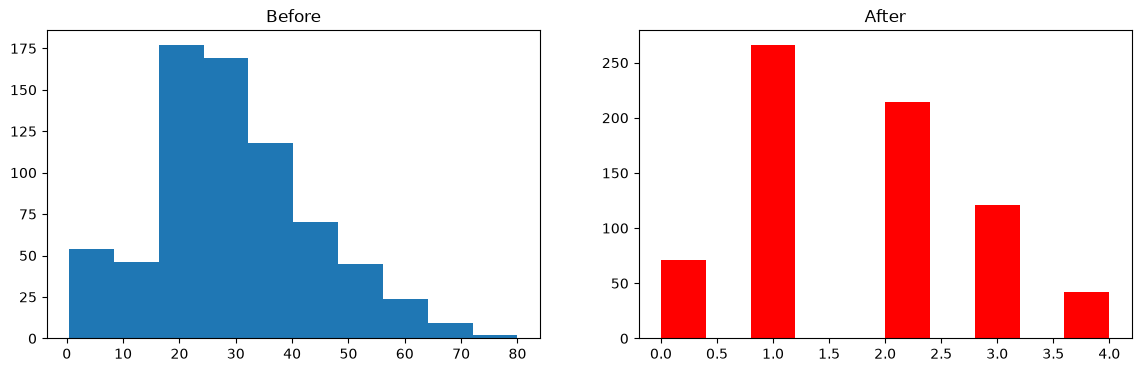

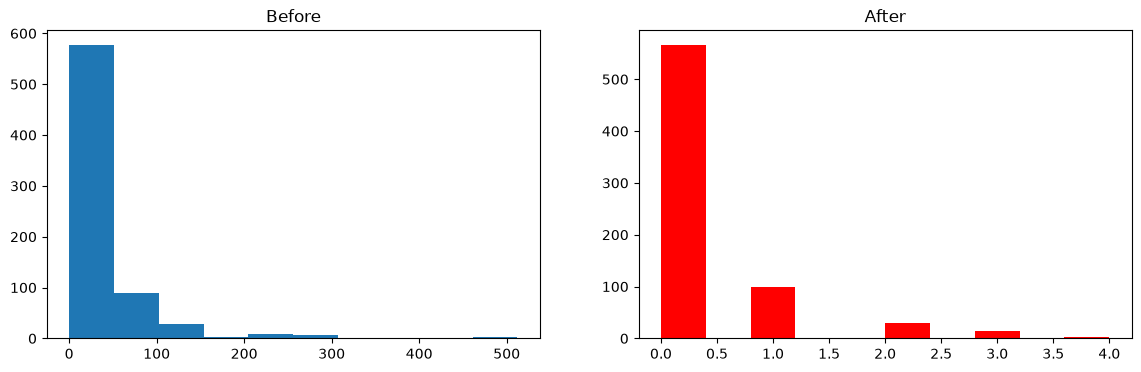

In [55]:
discretize(10,'uniform')

In [ ]:





















































\